# Breast Cancer Classification

___

### Load Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
# load dataset
df = pd.read_csv('dataset/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


___

## Data Preprocessing

In [3]:
# check unique values in diagnosis column
df.diagnosis.unique()

array(['M', 'B'], dtype=object)

'M' -> Malignint 

'B' -> Benign

In [4]:
#check dataframe summary
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
# check dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
# missing values
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

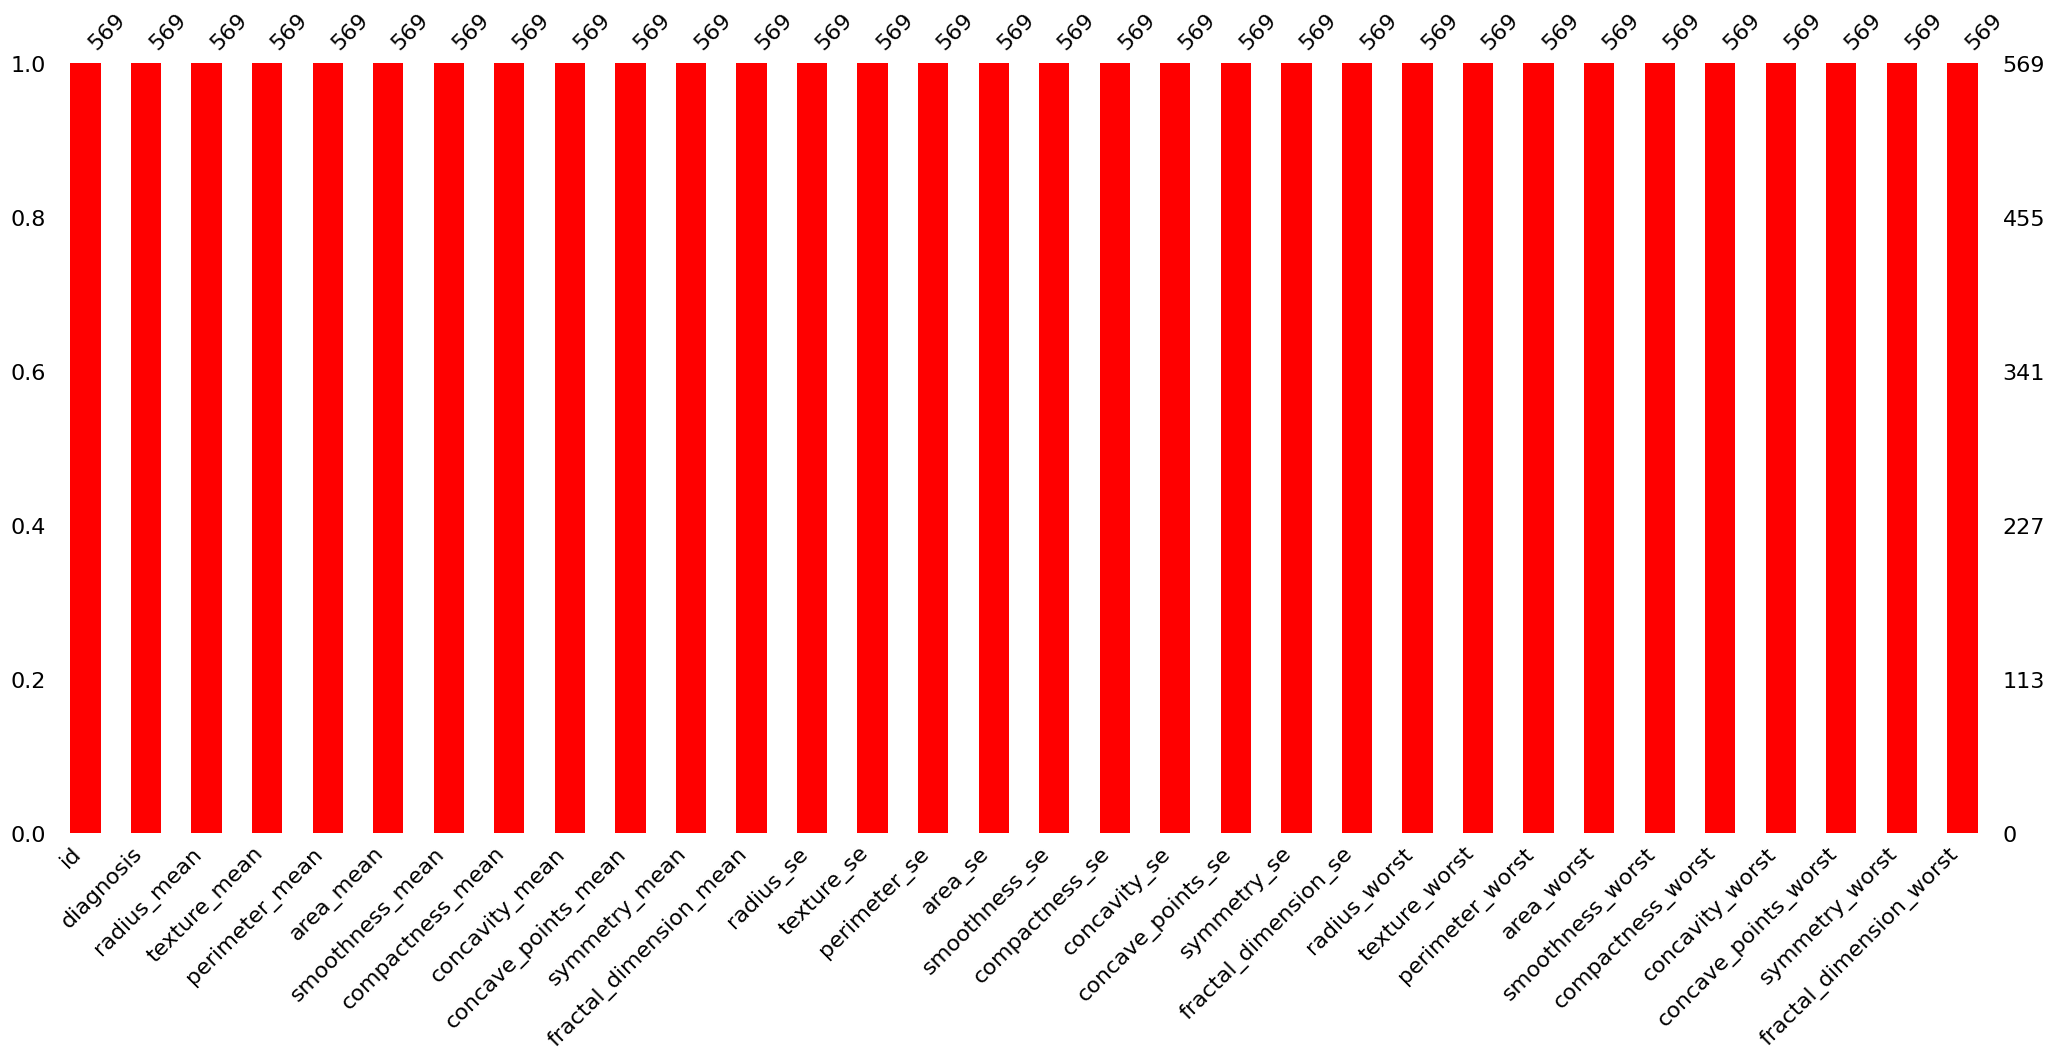

In [7]:
# missing values visualization
msno.bar(df, color="red")
plt.show()

As from above experiment it shows us that the data has no missing value

In [8]:
# Converting the diagnosis column into numeric values
df['diagnosis'] = df['diagnosis'].apply(lambda val:1 if val=='M' else 0)

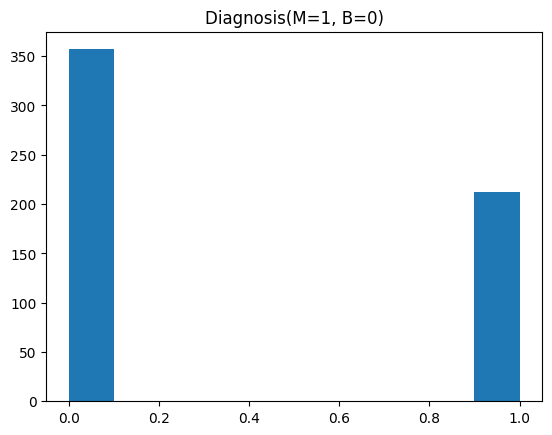

In [9]:
# Plotting a histogram of the diagnosis column
plt.hist(df['diagnosis'])
plt.title('Diagnosis(M=1, B=0)')
plt.show()

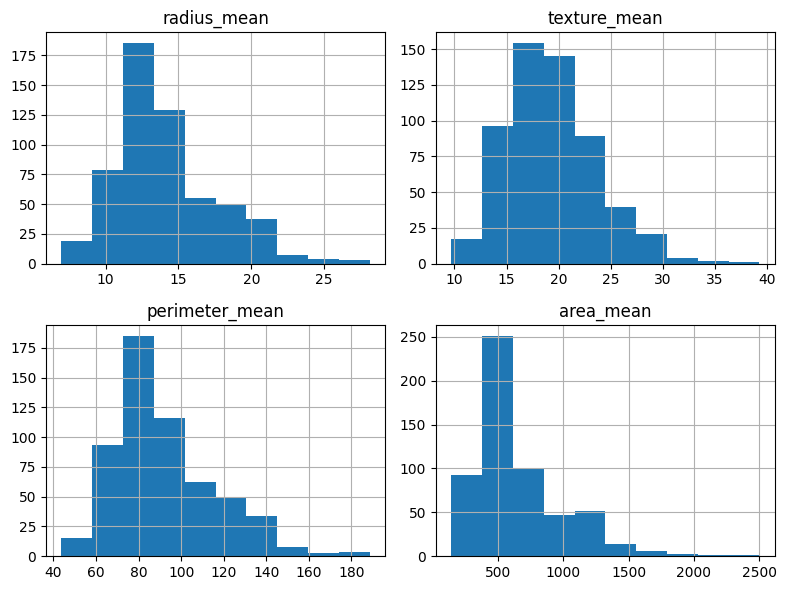

In [10]:
# Check feature distributions & outliers
num_cols = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
df[num_cols].hist(figsize=(8,6))
plt.tight_layout()
plt.show()

Exploratory Data Analysis (EDA)

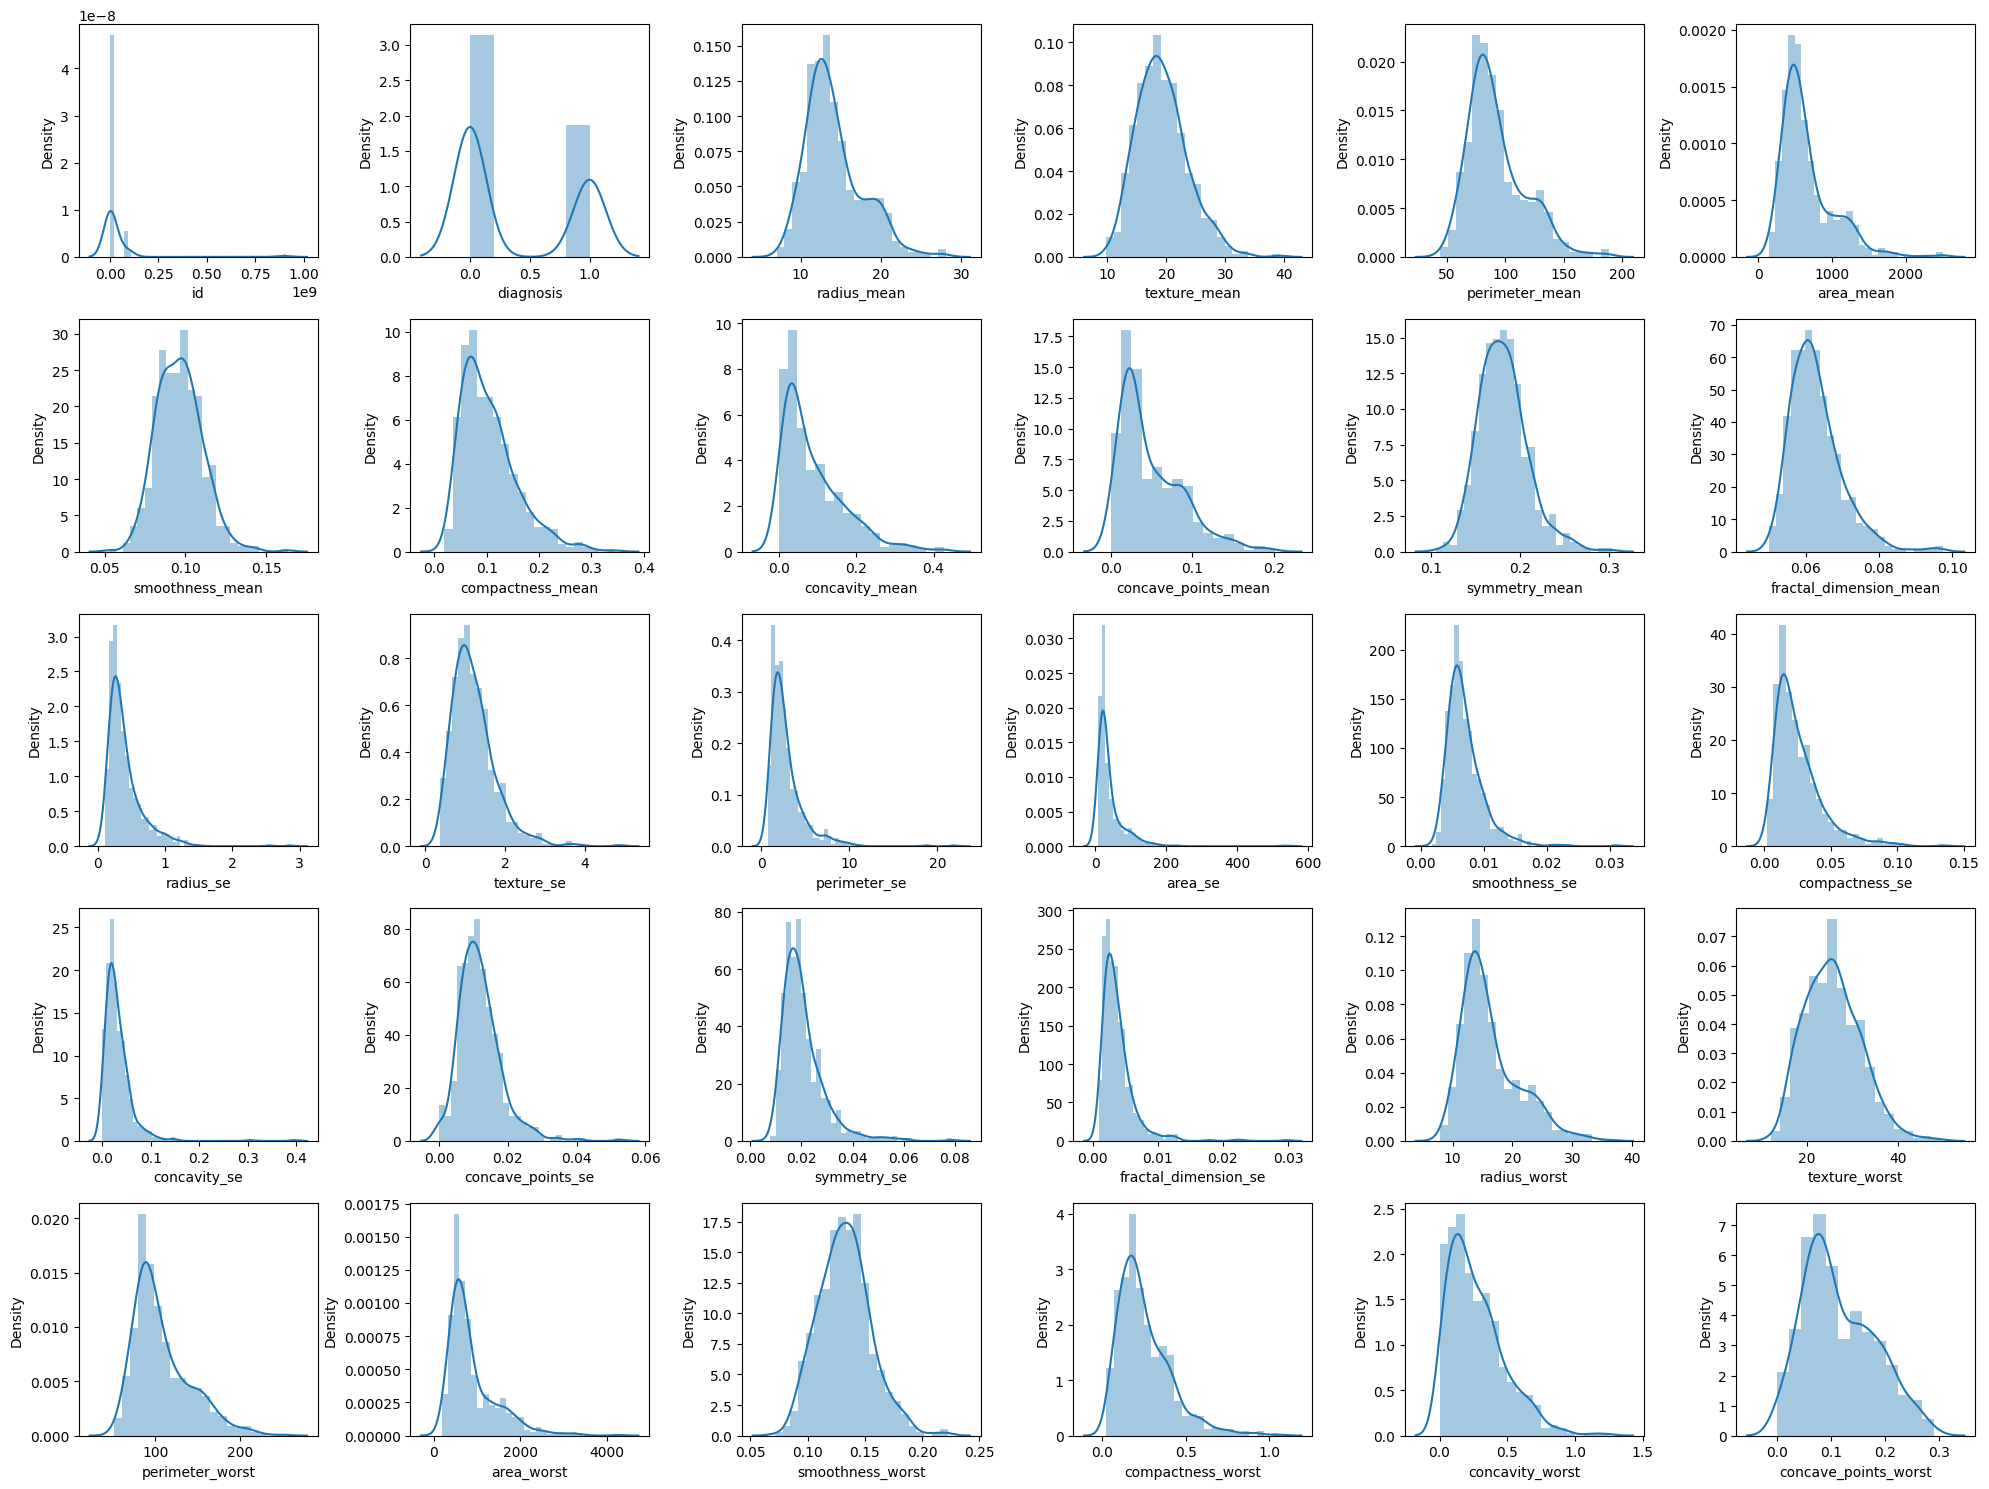

In [11]:

# density plot 
# visualize distribution of each feature in dataset

import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(20,15))
plotnumber=1
for column in df:
    if plotnumber<=30:
        ax = plt.subplot(5,6, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)
    plotnumber+=1

plt.tight_layout()
plt.show()

In [12]:
# calculate correlation matrix
df.corr()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.012968,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave_points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


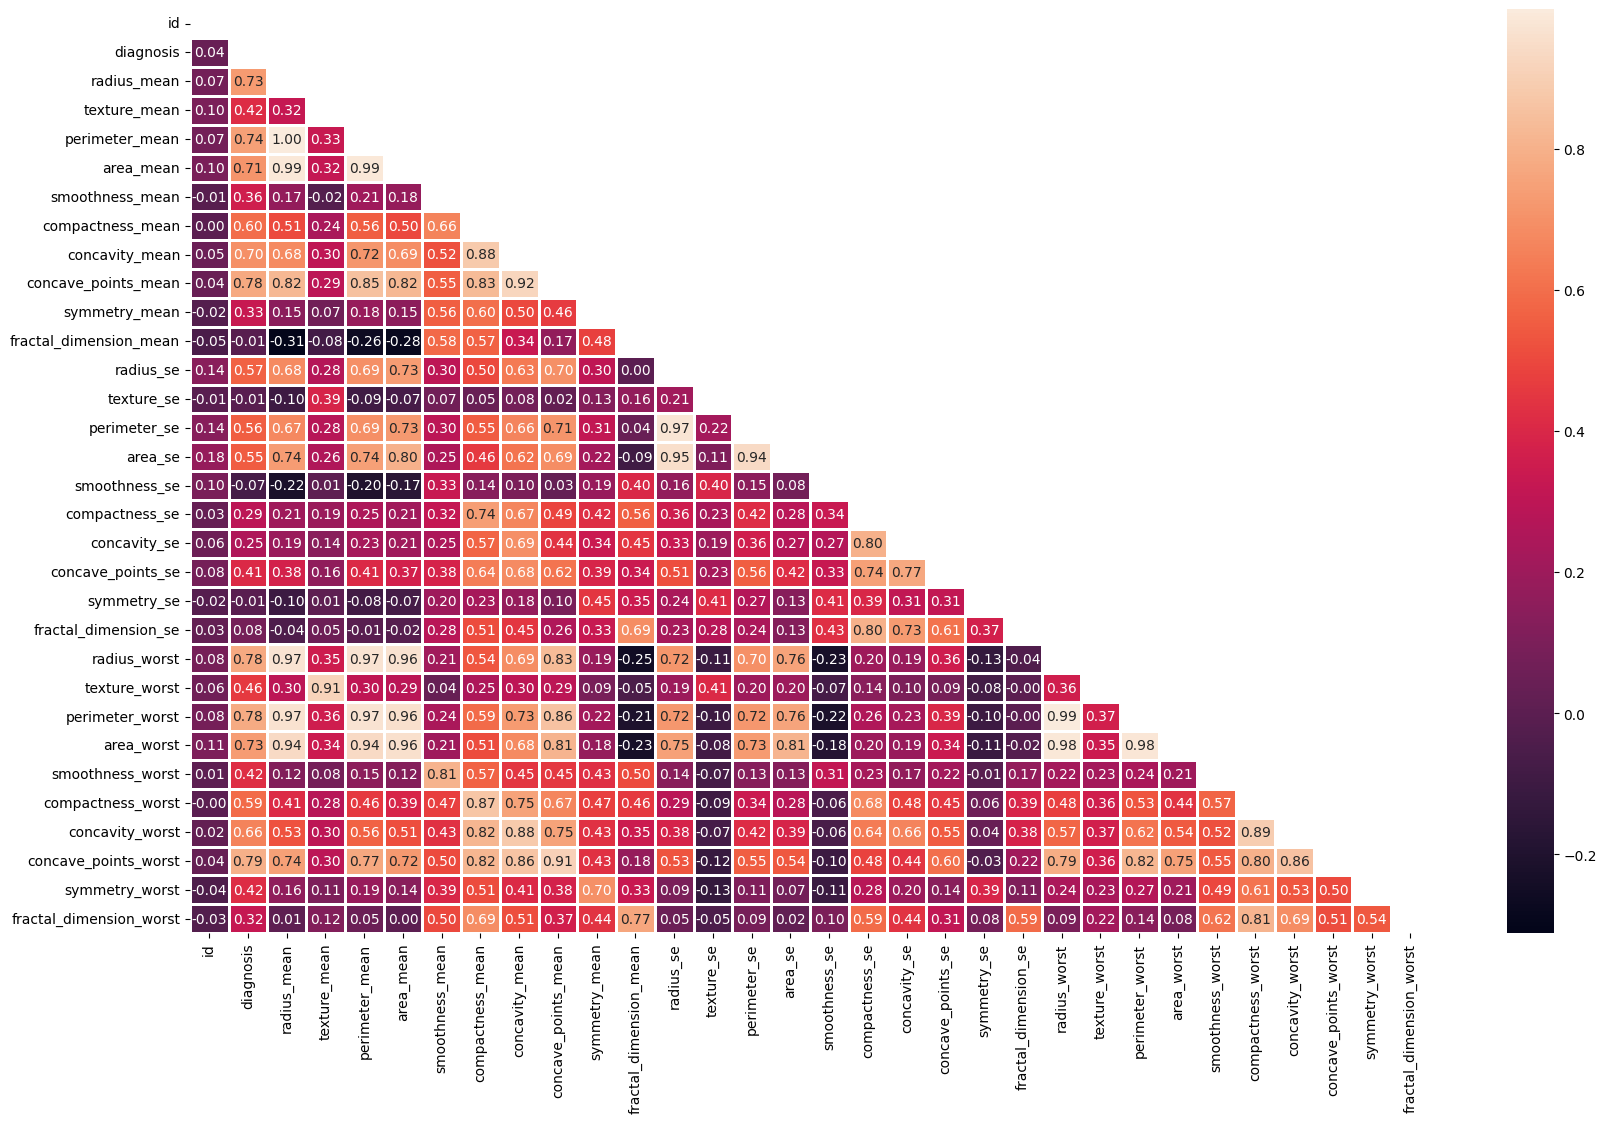

In [13]:
# create heatmap
plt.figure(figsize=(20,12))
corr=df.corr()

# Create a mask for the upper triangle to hide the upper triangle of the matrix.
mask = np.triu(np.ones_like(corr, dtype=bool)) 

sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt = ".2f")
plt.show()

In [14]:
# drop id column
df.drop('id', axis=1, inplace=True)

Drop highly correlated features having correlation more than 0.92

In [15]:
corr_matrix = df.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

to_drop = [x for x in tri_df.columns if any(tri_df[x] > 0.92)]
print(to_drop)
print(df.shape[1])

['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst']
31


In [16]:
# feature selection
df = df.drop(to_drop, axis=1)

print(df.shape[1])

23


We dropped 8 highly correlated featues now we have 23 columns instead of 31

In [17]:
df.head()

,diagnosis,texture_mean,smoothness_mean,compactness_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,smoothness_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,153.40,0.006399,...,0.03003,0.006193,17.33,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,74.08,0.005225,...,0.01389,0.003532,23.41,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,94.03,0.006150,...,0.02250,0.004571,25.53,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,27.23,0.009110,...,0.05963,0.009208,26.50,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,94.44,0.011490,...,0.01756,0.005115,16.67,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
X=df.drop('diagnosis', axis=1)
y=df['diagnosis']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
X_train.shape

(455, 22)

___

# Algorithm

## Logistic Regression

In [22]:
# logistic regression
from sklearn.linear_model import LogisticRegression
logistic_reg = LogisticRegression()
logistic_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
# predict
y_pred = logistic_reg.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1])

In [24]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_log = accuracy_score(y_train, logistic_reg.predict(X_train))
print(f'Train Accuracy: {accuracy_train_log*100:.2f}%')
accuracy_test_log = accuracy_score(y_test, logistic_reg.predict(X_test))
print(f'Test Accuracy: {accuracy_test_log*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = logistic_reg.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Train Accuracy: 98.68%
Test Accuracy: 97.37%

Confusion Matrix:
[[70  1]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## KNN (K-Nearest Neighbors)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
# predict
y_pred = knn.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [27]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_knn = accuracy_score(y_train, knn.predict(X_train))
print(f'Train Accuracy: {accuracy_train_knn*100:.2f}%')
accuracy_test_knn = accuracy_score(y_test, knn.predict(X_test))
print(f'Test Accuracy: {accuracy_test_knn*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Train Accuracy: 97.14%
Test Accuracy: 93.86%

Confusion Matrix:
[[68  3]
 [ 4 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



# Support Vector Machine (SVM)

In [28]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True)

# hyperparameter tuning
param_grid = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C': [0.01, 0.05, 0.5, 0.1, 1, 10, 15, 20]
}

grid_search = GridSearchCV(svc, param_grid)
grid_search.fit(X_train, y_train)

,estimator,SVC(probability=True)
,param_grid,"{'C': [0.01, 0.05, ...], 'gamma': [0.0001, 0.001, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,15


In [29]:
# best parameters
grid_search.best_params_

{'C': 15, 'gamma': 0.01}

In [30]:
# best score
grid_search.best_score_

np.float64(0.9714285714285715)

In [31]:
# train SVC with best parameters
svc = SVC(C=15, gamma=0.01, probability=True)
svc.fit(X_train, y_train)

,C,15
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
# predict
y_pred = svc.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [33]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_svc = accuracy_score(y_train, svc.predict(X_train))
print(f'Train Accuracy: {accuracy_train_svc*100:.2f}%')
accuracy_test_svc = accuracy_score(y_test, svc.predict(X_test))
print(f'Test Accuracy: {accuracy_test_svc*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = svc.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


Train Accuracy: 98.90%
Test Accuracy: 98.25%

Confusion Matrix:
[[71  0]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 32, 1),
    'min_samples_split': range(1, 10, 1),
    'min_samples_leaf': range(2, 10, 1),
    'splitter': ['best', 'random']
}

grid_search_dt = GridSearchCV_dtc = GridSearchCV(dtc, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 8640 candidates, totalling 43200 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(2, 32), 'min_samples_leaf': range(2, 10), 'min_samples_split': range(1, 10), ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [35]:
grid_search_dt.best_params_

{'criterion': 'gini',
 'max_depth': 19,
 'min_samples_leaf': 5,
 'min_samples_split': 4,
 'splitter': 'random'}

In [36]:
grid_search_dt.best_score_

np.float64(0.9626373626373625)

In [37]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=11, min_samples_leaf=4, min_samples_split=5, splitter='random')

In [38]:
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'random'
,max_depth,11
,min_samples_split,5
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_dtc = accuracy_score(y_train, dtc.predict(X_train))
print(f'Train Accuracy: {accuracy_train_dtc*100:.2f}%')
accuracy_test_dtc = accuracy_score(y_test, dtc.predict(X_test))
print(f'Test Accuracy: {accuracy_test_dtc*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = dtc.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Train Accuracy: 95.38%
Test Accuracy: 94.74%

Confusion Matrix:
[[68  3]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Random Forest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 10, max_features = 0.5, min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rand_clf.fit(X_train, y_train)

,n_estimators,130
,criterion,'entropy'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred = rand_clf.predict(X_test)


In [42]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_clf = accuracy_score(y_train, rand_clf.predict(X_train))
print(f'Train Accuracy: {accuracy_train_clf*100:.2f}%')
accuracy_test_clf = accuracy_score(y_test, rand_clf.predict(X_test))
print(f'Test Accuracy: {accuracy_test_clf*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = rand_clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Train Accuracy: 99.56%
Test Accuracy: 96.49%

Confusion Matrix:
[[70  1]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Gradient Boosting Classifier

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

parameters = {
    'loss': ['deviance', 'exponential'],
    'learning_rate': [0.001, 0.1],
    'n_estimators': [100, 150, 180]
}

grid_search_gbc = GridSearchCV(gbc, parameters, cv = 2, n_jobs = -5, verbose = 1)
grid_search_gbc.fit(X_train, y_train)

Fitting 2 folds for each of 12 candidates, totalling 24 fits


,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.001, 0.1], 'loss': ['deviance', 'exponential'], 'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,-5
,refit,True
,cv,2
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'exponential'


In [44]:
grid_search_gbc.best_params_


{'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 180}

In [45]:
grid_search_gbc.best_score_


np.float64(0.9626323518046217)

In [46]:
gbc = GradientBoostingClassifier(learning_rate = 0.1, loss = 'exponential', n_estimators = 180)
gbc.fit(X_train, y_train)

,loss,'exponential'
,learning_rate,0.1
,n_estimators,180
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [47]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_gbc = accuracy_score(y_train, gbc.predict(X_train))
print(f'Train Accuracy: {accuracy_train_gbc*100:.2f}%')
accuracy_test_gbc = accuracy_score(y_test, gbc.predict(X_test))
print(f'Test Accuracy: {accuracy_test_gbc*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = gbc.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Train Accuracy: 100.00%
Test Accuracy: 95.61%

Confusion Matrix:
[[69  2]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



XGB Classifier 

In [48]:
from xgboost import XGBClassifier 

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.01, max_depth = 5, n_estimators = 180)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
# test and train accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_train_xgb = accuracy_score(y_train, xgb.predict(X_train))
print(f'Train Accuracy: {accuracy_train_xgb*100:.2f}%')
accuracy_test_xgb = accuracy_score(y_test, xgb.predict(X_test))
print(f'Test Accuracy: {accuracy_test_xgb*100:.2f}%')

# confusion matrix
print("\nConfusion Matrix:")
y_pred = xgb.predict(X_test)
print(confusion_matrix(y_test, y_pred))

# classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Train Accuracy: 99.12%
Test Accuracy: 95.61%

Confusion Matrix:
[[69  2]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Check which model gives the best score

In [50]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree Classifier', 'Random Forest Classifier', 'Gradient Boosting Classifier', 'XgBoost'],
    'Score': [100*round(accuracy_test_log,4), 100*round(accuracy_test_knn,4), 100*round(accuracy_test_svc,4), 100*round(accuracy_test_dtc,4), 100*round(accuracy_test_clf,4), 
              100*round(accuracy_test_gbc,4), 100*round(accuracy_test_xgb,4)]
})
models.sort_values(by = 'Score', ascending = False)

,Model,Score
2,SVM,98.25
0,Logistic Regression,97.37
4,Random Forest Classifier,96.49
5,Gradient Boosting Classifier,95.61
6,XgBoost,95.61
3,Decision Tree Classifier,94.74
1,KNN,93.86


 ROC (Receiver Operating Characteristic) curve comparison plot

In [51]:
from sklearn import metrics
plt.figure(figsize=(8,5))
classifiers = [
{
    'label': 'LR',
    'model': logistic_reg,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]




<Figure size 800x500 with 0 Axes>

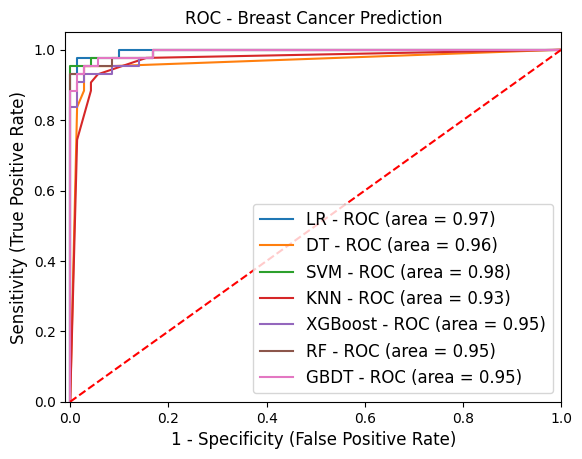

In [52]:
for clf in classifiers:
    estimator = clf['model'] 
    estimator.fit(X_train, y_train) 
    predictions = estimator.predict(X_test) 
    fpr, tpr, thresh = metrics.roc_curve(y_test, estimator.predict_proba(X_test)[:,1])
    auc_score = metrics.roc_auc_score(y_test, estimator.predict(X_test))
    plt.plot(fpr, tpr, label='%s - ROC (area = %0.2f)' % (clf['label'], auc_score))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Breast Cancer Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

In [53]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
models = [
{
    'label': 'LR',
    'model': logistic_reg,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]


In [54]:
roc_scores = []
accuracy_scores = [100*round(accuracy_test_log,4), 100*round(accuracy_test_knn,4), 100*round(accuracy_test_svc,4), 100*round(accuracy_test_dtc,4), 100*round(accuracy_test_clf,4), 
              100*round(accuracy_test_gbc,4), 100*round(accuracy_test_xgb,4)]

for clf in models:
    estimator = clf['model'] 
    estimator.fit(X_train, y_train) 
    predictions = estimator.predict(X_test) 
    fpr, tpr, thresh = metrics.roc_curve(y_test, estimator.predict_proba(X_test)[:,1])
    auc_score = metrics.roc_auc_score(y_test, estimator.predict(X_test))
    auc_score = 100*round(auc_score,4)
    roc_scores.append(auc_score)

print(accuracy_scores)
print(roc_scores)

[97.37, 93.86, 98.25, 94.74000000000001, 96.49, 95.61, 95.61]
[96.97, 90.66, 97.67, 93.24, 95.1, 95.1, 95.1]


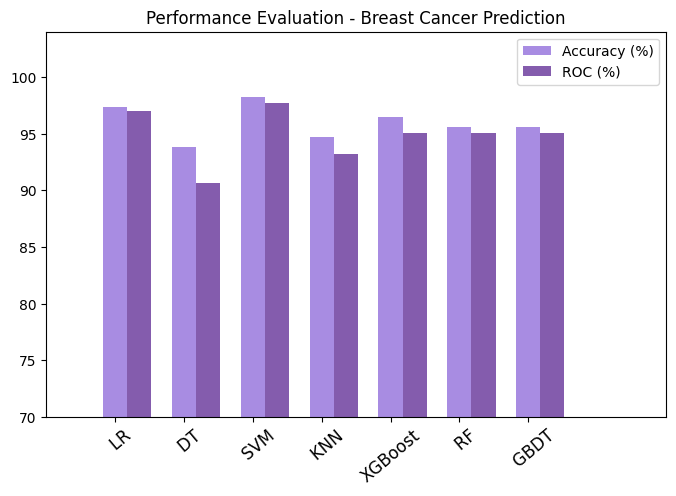

In [55]:
# data to plot
num_models = 7
accuracy_data = tuple(accuracy_scores)
roc_data = tuple(roc_scores)

# create plot
fig, ax = plt.subplots(figsize=(8,5))
x_pos = np.arange(num_models)
bar_width = 0.35
opacity = 0.8

accuracy_bars = plt.bar(x_pos, accuracy_data, bar_width,
alpha=opacity,
color='mediumpurple',
label='Accuracy (%)')

roc_bars = plt.bar(x_pos + bar_width, roc_data, bar_width,
alpha=opacity,
color='rebeccapurple',
label='ROC (%)')

plt.xlim([-1, 8])
plt.ylim([70, 104])

plt.title('Performance Evaluation - Breast Cancer Prediction', fontsize=12)
plt.xticks(x_pos, ('   LR', '   DT', '   SVM', '   KNN', 'XGBoost' , '   RF', '   GBDT'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.savefig("PE_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()